# Checkpoint 1 

Neste checkpoint, o objetivo é testar dois modelos para classificação de textos:
1. Um modelo com implementação própria em NumPy;
2. Um modelo equivalente em PyTorch.

## Imports

In [61]:
import re
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from activation import ReLUActivation, SigmoidActivation
from layers import DenseLayer, DropoutLayer
from losses import BinaryCrossEntropy
from neuralnetwork import NeuralNetwork

## Dataset

In [62]:
df = pd.read_csv("DatasetFinal/dataset_final.csv")
df.head()

,Text,source_name,source_code
0,By . Daily Mail Reporter . A former North Kore...,human,0
1,"i dont like working in teams, its too much hassle",human,0
2,We summarize a theoretical framework based o...,human,0
3,13 Disastrous Vending Machine FAILS (PHOTOS)\n...,meta,3
4,"However , net sales in 2010 are seen to have g...",human,0


In [63]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15555 entries, 0 to 15554
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Text         15555 non-null  str  
 1   source_name  15555 non-null  str  
 2   source_code  15555 non-null  int64
dtypes: int64(1), str(2)
memory usage: 24.8 MB


In [64]:
df["source_name"].value_counts()

source_name
human      7650
openai     2435
google     1900
meta       1838
mistral    1732
Name: count, dtype: int64

## Análise inicial do dataset

O dataset contém textos classificados por origem.  
As classes disponíveis são:

- human
- openai
- google
- meta
- mistral

Para esta primeira abordagem, vamos converter o problema para classificação binária:
- **human = 0**
- **qualquer modelo LLM = 1**

In [65]:
df["binary_label"] = (df["source_name"] != "human").astype(int)
df[["source_name", "binary_label"]].head()

df["binary_label"].value_counts()

#df["binary_label"].value_counts(normalize=True) * 100 #PERCENTAGEM

binary_label
1    7905
0    7650
Name: count, dtype: int64

## Visualização Gráfica

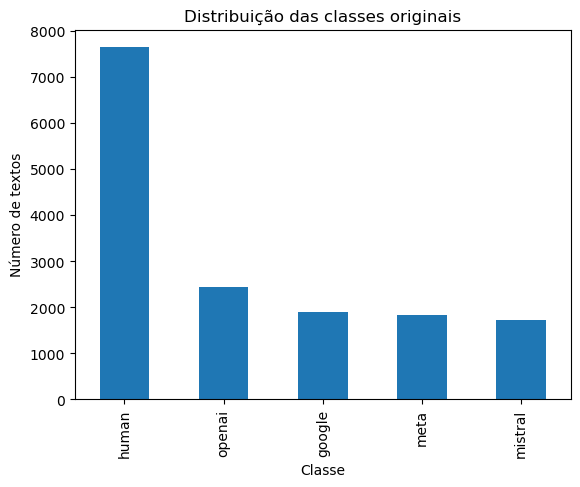

In [66]:
df["source_name"].value_counts().plot(kind="bar")
plt.title("Distribuição das classes originais")
plt.xlabel("Classe")
plt.ylabel("Número de textos")
plt.show()

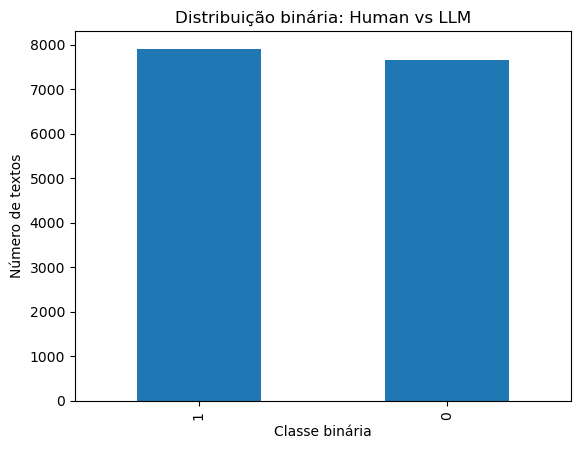

In [67]:
df["binary_label"].value_counts().plot(kind="bar")
plt.title("Distribuição binária: Human vs LLM")
plt.xlabel("Classe binária")
plt.ylabel("Número de textos")
plt.show()

## Pré-Processamento

In [68]:
X_text = df["Text"].astype(str)
y = df["binary_label"].values

In [69]:
def train_test_split_manual(X, y, test_size=0.2, random_state=42):
    rng = np.random.default_rng(random_state)

    class_0_idx = np.where(y == 0)[0]
    class_1_idx = np.where(y == 1)[0]

    rng.shuffle(class_0_idx)
    rng.shuffle(class_1_idx)

    n0_test = int(len(class_0_idx) * test_size)
    n1_test = int(len(class_1_idx) * test_size)

    test_idx = np.concatenate([class_0_idx[:n0_test], class_1_idx[:n1_test]])
    train_idx = np.concatenate([class_0_idx[n0_test:], class_1_idx[n1_test:]])

    rng.shuffle(train_idx)
    rng.shuffle(test_idx)

    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]

X_train_text, X_test_text, y_train, y_test = train_test_split_manual(
    X_text, y, test_size=0.2, random_state=42
)

print("Train size:", len(X_train_text))
print("Test size:", len(X_test_text))

Train size: 12444
Test size: 3111


In [70]:
STOPWORDS = {
    "the", "a", "an", "and", "or", "of", "to", "in", "on", "at", "for", "with",
    "is", "are", "was", "were", "be", "been", "being", "this", "that", "these",
    "those", "it", "its", "as", "by", "from", "but", "about", "into", "than",
    "then", "so", "such", "if", "their", "there", "they", "them", "he", "she",
    "you", "your", "we", "our", "i", "my", "me", "his", "her", "what", "which",
    "who", "whom", "can", "could", "should", "would", "do", "does", "did", "have",
    "has", "had", "not", "no", "yes", "will", "just"
}

def tokenize(text):
    text = text.lower()
    tokens = re.findall(r"\b[a-zA-ZÀ-ÿ]{2,}\b", text)
    return [tok for tok in tokens if tok not in STOPWORDS]

def build_vocabulary(texts, max_features=5000):
    counter = Counter()
    for text in texts:
        counter.update(tokenize(text))
    most_common = counter.most_common(max_features)
    vocab = {word: idx for idx, (word, _) in enumerate(most_common)}
    return vocab

def compute_idf(tokenized_texts, vocab):
    n_docs = len(tokenized_texts)
    df_counts = np.zeros(len(vocab), dtype=np.float64)

    for tokens in tokenized_texts:
        unique_tokens = set(tok for tok in tokens if tok in vocab)
        for tok in unique_tokens:
            df_counts[vocab[tok]] += 1

    idf = np.log((1 + n_docs) / (1 + df_counts)) + 1
    return idf

def vectorize_tfidf(texts, vocab, idf):
    X = np.zeros((len(texts), len(vocab)), dtype=np.float64)

    for i, text in enumerate(texts):
        tokens = [tok for tok in tokenize(text) if tok in vocab]
        if not tokens:
            continue

        counts = Counter(tokens)
        total_terms = len(tokens)

        for tok, count in counts.items():
            j = vocab[tok]
            tf = count / total_terms
            X[i, j] = tf * idf[j]

    return X

vocab = build_vocabulary(X_train_text, max_features=5000)

train_tokens = [tokenize(text) for text in X_train_text]
idf = compute_idf(train_tokens, vocab)

X_train = vectorize_tfidf(X_train_text, vocab, idf)
X_test = vectorize_tfidf(X_test_text, vocab, idf)

print("Vocabulary size:", len(vocab))
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

Vocabulary size: 5000
X_train shape: (12444, 5000)
X_test shape: (3111, 5000)


In [71]:
# ajuste ao neuralnetwork.py

class SimpleDataset:
    def __init__(self, X, y):
        self.X = X
        self.y = y

train_data = SimpleDataset(X_train, y_train)
test_data = SimpleDataset(X_test, y_test)

# Baseline

In [72]:
baseline_model = NeuralNetwork(
    epochs=20,
    batch_size=64,
    learning_rate=0.01,
    momentum=0.9,
    verbose=True,
    loss=BinaryCrossEntropy
)

baseline_model.add(DenseLayer(1, input_shape=(X_train.shape[1],)))
baseline_model.add(SigmoidActivation())

In [73]:
baseline_model.fit(train_data)

Epoch 1/20 - loss: 0.6933 - mean_squared_error: 0.2501


Epoch 2/20 - loss: 0.6914 - mean_squared_error: 0.2491
Epoch 3/20 - loss: 0.6895 - mean_squared_error: 0.2482
Epoch 4/20 - loss: 0.6876 - mean_squared_error: 0.2473
Epoch 5/20 - loss: 0.6858 - mean_squared_error: 0.2463
Epoch 6/20 - loss: 0.6841 - mean_squared_error: 0.2455
Epoch 7/20 - loss: 0.6823 - mean_squared_error: 0.2446
Epoch 8/20 - loss: 0.6807 - mean_squared_error: 0.2438
Epoch 9/20 - loss: 0.6790 - mean_squared_error: 0.2429
Epoch 10/20 - loss: 0.6773 - mean_squared_error: 0.2421
Epoch 11/20 - loss: 0.6757 - mean_squared_error: 0.2413
Epoch 12/20 - loss: 0.6741 - mean_squared_error: 0.2405
Epoch 13/20 - loss: 0.6726 - mean_squared_error: 0.2398
Epoch 14/20 - loss: 0.6710 - mean_squared_error: 0.2390
Epoch 15/20 - loss: 0.6695 - mean_squared_error: 0.2383
Epoch 16/20 - loss: 0.6680 - mean_squared_error: 0.2375
Epoch 17/20 - loss: 0.6665 - mean_squared_error: 0.2368
Epoch 18/20 - loss: 0.6651 - mean_squared_error: 0.2361
Epoch 19/20 - loss: 0.6637 - mean_squared_error: 0.2354


In [74]:
y_pred_prob_baseline = baseline_model.predict(test_data)
y_pred_baseline = (y_pred_prob_baseline >= 0.5).astype(int).flatten()

In [75]:
def accuracy_score_manual(y_true, y_pred):
    return np.mean(y_true == y_pred)

def confusion_matrix_manual(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    return np.array([[tn, fp],
                     [fn, tp]])

def precision_score_manual(y_true, y_pred):
    cm = confusion_matrix_manual(y_true, y_pred)
    tp = cm[1, 1]
    fp = cm[0, 1]
    return tp / (tp + fp) if (tp + fp) > 0 else 0.0

def recall_score_manual(y_true, y_pred):
    cm = confusion_matrix_manual(y_true, y_pred)
    tp = cm[1, 1]
    fn = cm[1, 0]
    return tp / (tp + fn) if (tp + fn) > 0 else 0.0

def f1_score_manual(y_true, y_pred):
    precision = precision_score_manual(y_true, y_pred)
    recall = recall_score_manual(y_true, y_pred)
    return 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

def classification_report_manual(y_true, y_pred):
    precision_0 = precision_score_manual(1 - y_true, 1 - y_pred)
    recall_0 = recall_score_manual(1 - y_true, 1 - y_pred)
    f1_0 = f1_score_manual(1 - y_true, 1 - y_pred)
    support_0 = np.sum(y_true == 0)

    precision_1 = precision_score_manual(y_true, y_pred)
    recall_1 = recall_score_manual(y_true, y_pred)
    f1_1 = f1_score_manual(y_true, y_pred)
    support_1 = np.sum(y_true == 1)

    print("Classe\tPrecision\tRecall\t\tF1-score\tSupport")
    print(f"human\t{precision_0:.4f}\t\t{recall_0:.4f}\t\t{f1_0:.4f}\t\t{support_0}")
    print(f"LLM\t{precision_1:.4f}\t\t{recall_1:.4f}\t\t{f1_1:.4f}\t\t{support_1}")

baseline_accuracy = accuracy_score_manual(y_test, y_pred_baseline)
baseline_precision = precision_score_manual(y_test, y_pred_baseline)
baseline_recall = recall_score_manual(y_test, y_pred_baseline)
baseline_f1 = f1_score_manual(y_test, y_pred_baseline)

print("Accuracy:", baseline_accuracy)
print("Precision:", baseline_precision)
print("Recall:", baseline_recall)
print("F1-score:", baseline_f1)

Accuracy: 0.7190613950498232
Precision: 0.6493451626531475
Recall: 0.9721695129664769
F1-score: 0.7786220871327254


## DNN(NumPy)

In [76]:
model = NeuralNetwork(
    epochs=60,
    batch_size=64,
    learning_rate=0.001,
    momentum=0.9,
    verbose=True,
    loss=BinaryCrossEntropy
)

model.add(DenseLayer(64, input_shape=(X_train.shape[1],)))
model.add(ReLUActivation())

model.add(DropoutLayer(0.2))

model.add(DenseLayer(1))
model.add(SigmoidActivation())

In [77]:
model.fit(train_data)

Epoch 1/60 - loss: 0.6927 - mean_squared_error: 0.2498
Epoch 2/60 - loss: 0.6926 - mean_squared_error: 0.2497
Epoch 3/60 - loss: 0.6923 - mean_squared_error: 0.2496
Epoch 4/60 - loss: 0.6922 - mean_squared_error: 0.2495
Epoch 5/60 - loss: 0.6920 - mean_squared_error: 0.2494
Epoch 6/60 - loss: 0.6917 - mean_squared_error: 0.2493
Epoch 7/60 - loss: 0.6916 - mean_squared_error: 0.2492
Epoch 8/60 - loss: 0.6914 - mean_squared_error: 0.2491
Epoch 9/60 - loss: 0.6912 - mean_squared_error: 0.2490
Epoch 10/60 - loss: 0.6911 - mean_squared_error: 0.2490
Epoch 11/60 - loss: 0.6909 - mean_squared_error: 0.2489
Epoch 12/60 - loss: 0.6907 - mean_squared_error: 0.2488
Epoch 13/60 - loss: 0.6907 - mean_squared_error: 0.2488
Epoch 14/60 - loss: 0.6904 - mean_squared_error: 0.2486
Epoch 15/60 - loss: 0.6903 - mean_squared_error: 0.2486
Epoch 16/60 - loss: 0.6901 - mean_squared_error: 0.2485
Epoch 17/60 - loss: 0.6899 - mean_squared_error: 0.2484
Epoch 18/60 - loss: 0.6898 - mean_squared_error: 0.2483
E

In [78]:
y_pred_prob = model.predict(test_data)
y_pred = (y_pred_prob >= 0.5).astype(int).flatten()

print(y_pred_prob[:10])
print(y_pred[:10])

[[0.51561758]
 [0.51883273]
 [0.49459705]
 [0.50690058]
 [0.50760905]
 [0.47380625]
 [0.5225078 ]
 [0.51130178]
 [0.5104308 ]
 [0.50659293]]
[1 1 0 1 1 0 1 1 1 1]


In [79]:
dnn_accuracy = accuracy_score_manual(y_test, y_pred)
dnn_precision = precision_score_manual(y_test, y_pred)
dnn_recall = recall_score_manual(y_test, y_pred)
dnn_f1 = f1_score_manual(y_test, y_pred)

print("Accuracy:", dnn_accuracy)
print("Precision:", dnn_precision)
print("Recall:", dnn_recall)
print("F1-score:", dnn_f1)

print("\nClassification report:")
classification_report_manual(y_test, y_pred)

cm = confusion_matrix_manual(y_test, y_pred)
print("\nConfusion matrix:")
print(cm)

Accuracy: 0.5972356155576984
Precision: 0.5624048706240488
Recall: 0.9348513598987982
F1-score: 0.702304585412212

Classification report:
Classe	Precision	Recall		F1-score	Support
human	0.7867		0.2484		0.3775		1530
LLM	0.5624		0.9349		0.7023		1581

Confusion matrix:
[[ 380 1150]
 [ 103 1478]]


In [80]:
comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression (NumPy)", "DNN (NumPy)"],
    "Accuracy": [baseline_accuracy, dnn_accuracy],
    "Precision": [baseline_precision, dnn_precision],
    "Recall": [baseline_recall, dnn_recall],
    "F1-score": [baseline_f1, dnn_f1]
})

comparison_df

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression (NumPy),0.719061,0.649345,0.972170,0.778622
1,DNN (NumPy),0.597236,0.562405,0.934851,0.702305
